# FM phase-diagram fit playground

Interactive exploration of the Fredenhagen–Marcu curves extracted by
`Three_TC/fm.py` (pulled to `results/phase_hx*_*/`). Self-contained —
**pure numpy/scipy/matplotlib, no NetKet** — so it runs locally.

What you can do (all driven from the **CONFIG** cell):
- **drop bad points per L** (`EXCLUDE = {L: [hz, ...]}`) — e.g. collapsed runs;
- **restrict an hz window** applied to every L (`HZ_WINDOW`);
- **swap the per-L transition fit** form (`logistic | tanh | erf`);
- **swap the FSS form** for `h_c(L)` — including your `h0 + (b/L)**x` — and read
  off `h_0`; compare `h_0` across *all* forms in one table;
- fit **O_FM or ⟨σz⟩**, weight by errorbars, subset which L enter the FSS, fix the
  FSS exponent, and jackknife (leave-one-L-out) `h_0` for a stability estimate.

Re-run from the CONFIG cell down after any change.

In [9]:
%matplotlib inline
import glob, json, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

## 1 · CONFIG — the one cell to edit

In [12]:
# ---- data ------------------------------------------------------------------
DATA_DIR = "/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/results/phase_hx0.0_bulk"
OBS      = "O"          # "O" = O_FM   |   "mz" = <sigma_z>

# ---- point selection -------------------------------------------------------
# EXCLUDE  = {6: [0.24, 0.36]}   # {L: [hz, ...]} bad/collapsed points to drop
HZ_WINDOW = None               # None, or (lo, hi) hz window applied to every L

# ---- per-L transition fit --------------------------------------------------
PERL_FORM = "logistic"         # "logistic" | "tanh" | "erf"  (h_c = inflection)

# ---- finite-size scaling of h_c(L) -----------------------------------------
#   linear_invL : h0 + a/L               (2 params)
#   power_x     : h0 + (b/L)**x          (3 params; your form)
#   power_free  : h0 + a*L**(-w)         (3 params; a = b**x reparam, better conditioned)
FSS_FORM  = "power_x"
FSS_FIX_X = None               # float -> FIX the exponent (x or w); frees a dof
FSS_LS    = None               # e.g. [4,5,6] subset of L for the FSS (None = all)

# ---- shared ----------------------------------------------------------------
WEIGHTED  = True               # use the fit errorbars as curve_fit sigma

In [ ]:
# quick look -- raw O_FM(h_z) points for every L in DATA_DIR (no fit, no exclusions).
# Self-contained (globs DATA_DIR itself) so it runs right after the CONFIG cell,
# before the load/fit machinery below.
_recs = sorted((json.load(open(jp))
                for jp in glob.glob(os.path.join(DATA_DIR, "fm_L*.json"))),
               key=lambda r: r["L"])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for rec, c in zip(_recs, plt.cm.viridis(np.linspace(0, 0.85, max(len(_recs), 1)))):
    hz = np.array(rec["field"], float)
    O  = np.array(rec["O"], float)
    Oe = np.array(rec.get("Oe", np.zeros_like(O)), float)
    ax.errorbar(hz, O, yerr=Oe, fmt="-o", ms=4, capsize=2, lw=0.8, color=c,
                label=f"L={rec['L']}")
ax.set(xlabel="$h_z$", ylabel="$O_{FM}$", title="raw $O_{FM}(h_z)$ -- data only")
ax.legend(); plt.tight_layout(); plt.show()

## 2 · Load + point selection

In [13]:
def load_curves(directory):
    recs = [json.load(open(jp))
            for jp in sorted(glob.glob(os.path.join(directory, "fm_L*.json")))]
    if not recs:
        raise SystemExit(f"no fm_L*.json in {directory} — pull the extracted curves first")
    return sorted(recs, key=lambda r: r["L"])

def get_arrays(rec, obs=None, exclude=None, window=None):
    """(hz, y, ye) for one L after applying EXCLUDE + HZ_WINDOW."""
    obs = OBS if obs is None else obs
    exclude = EXCLUDE if exclude is None else exclude
    window = HZ_WINDOW if window is None else window
    hz = np.array(rec["field"], float)
    y  = np.array(rec[obs], float)
    ye = np.array(rec.get("Oe" if obs == "O" else "mz_e", np.zeros_like(y)), float)
    keep = np.ones(len(hz), bool)
    for h in exclude.get(rec["L"], []):
        keep &= ~np.isclose(hz, h, atol=1e-6)
    if window is not None:
        keep &= (hz >= window[0]) & (hz <= window[1])
    return hz[keep], y[keep], ye[keep]

recs = load_curves(DATA_DIR)
_r0 = recs[0]
print(f"loaded L = {[r['L'] for r in recs]}   "
      f"placement = {_r0.get('placement','?')}   hx = {_r0.get('hx','?')}   obs = {OBS}")
for r in recs:
    hz, y, ye = get_arrays(r)
    print(f"  L={r['L']}: {len(hz):2d} pts kept "
          f"(dropped {len(r['field']) - len(hz)})   hz in [{hz.min():.3g}, {hz.max():.3g}]")

loaded L = [4, 5, 6, 7]   placement = bulk   hx = 0.0   obs = O
  L=4: 13 pts kept (dropped 0)   hz in [0.1, 0.4]
  L=5: 13 pts kept (dropped 0)   hz in [0.1, 0.4]
  L=6: 13 pts kept (dropped 0)   hz in [0.1, 0.4]
  L=7: 12 pts kept (dropped 0)   hz in [0.1, 0.375]


## 3 · Per-L transition fit

  L  npts      h_c  h_c_err   hc_fd   width
  4    13   0.3189   0.0026   0.338  0.0263
  5    13   0.2957   0.0016   0.287  0.0210
  6    13   0.2886   0.0010   0.287  0.0150
  7    12   0.2791   0.0010   0.287  0.0124


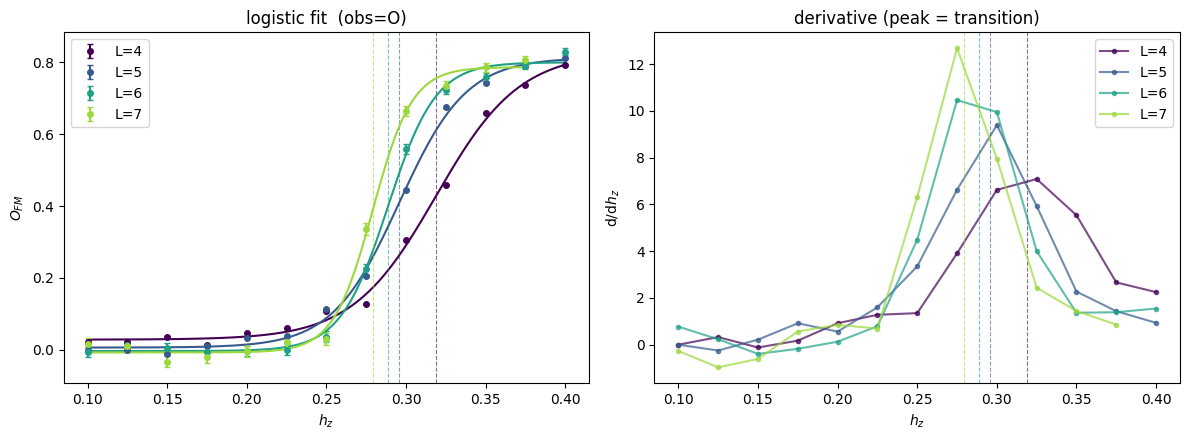

In [14]:
# --- sigmoid family: all have an inflection at h0 (= the pseudo-critical field) ---
def _logistic(h, a, b, h0, w): return a + b / (1.0 + np.exp(-(h - h0) / w))
def _tanh(h, a, b, h0, w):     return a + b * np.tanh((h - h0) / w)
def _erf(h, a, b, h0, w):      return a + b * erf((h - h0) / w)
PERL = {"logistic": _logistic, "tanh": _tanh, "erf": _erf}

def _p0(form, hz, y):
    rng = (hz[-1] - hz[0]) or 1.0
    if form == "logistic":
        return [y[0], y[-1] - y[0], float(np.median(hz)), 0.1 * rng]
    return [0.5 * (y[0] + y[-1]), 0.5 * (y[-1] - y[0]), float(np.median(hz)), 0.1 * rng]

def fit_transition(hz, y, ye, form=None, weighted=None):
    """Fit the chosen sigmoid; return h_c (= inflection h0), its error, curve, width,
    and a model-free finite-difference derivative-peak cross-check."""
    form = PERL_FORM if form is None else form
    weighted = WEIGHTED if weighted is None else weighted
    f = PERL[form]
    kw = dict(sigma=ye, absolute_sigma=True) if (weighted and np.all(ye > 0)) else {}
    popt, pcov = curve_fit(f, hz, y, p0=_p0(form, hz, y), maxfev=40000, **kw)
    hh = np.linspace(hz.min(), hz.max(), 400)
    hm = 0.5 * (hz[1:] + hz[:-1]); d = np.diff(y) / np.diff(hz)
    hc_fd = float(hm[int(np.argmax(np.abs(d)))]) if len(hm) else float("nan")
    return dict(popt=popt, h_c=float(popt[2]), h_c_err=float(np.sqrt(abs(pcov[2, 2]))),
                width=abs(float(popt[3])), hc_fd=hc_fd, curve=(hh, f(hh, *popt)))

fits = {}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(recs)))
ylab = r"$O_{FM}$" if OBS == "O" else r"$\langle\sigma_z\rangle$"
print(f"{'L':>3} {'npts':>5} {'h_c':>8} {'h_c_err':>8} {'hc_fd':>7} {'width':>7}")
for rec, c in zip(recs, colors):
    L = rec["L"]
    hz, y, ye = get_arrays(rec)
    fit = fit_transition(hz, y, ye); fits[L] = fit
    ax[0].errorbar(hz, y, yerr=ye, fmt="o", ms=4, capsize=2, color=c, label=f"L={L}")
    hh, yy = fit["curve"]; ax[0].plot(hh, yy, "-", color=c)
    ax[0].axvline(fit["h_c"], ls="--", color=c, lw=0.8, alpha=0.6)
    ax[1].plot(hz, np.gradient(y, hz), "o-", ms=3, color=c, alpha=0.7, label=f"L={L}")
    ax[1].axvline(fit["h_c"], ls="--", color=c, lw=0.8, alpha=0.6)
    print(f"{L:>3} {len(hz):>5} {fit['h_c']:>8.4f} {fit['h_c_err']:>8.4f} "
          f"{fit['hc_fd']:>7.3f} {fit['width']:>7.4f}")
ax[0].set(xlabel="$h_z$", ylabel=ylab, title=f"{PERL_FORM} fit  (obs={OBS})"); ax[0].legend()
ax[1].set(xlabel="$h_z$", ylabel="d/d$h_z$", title="derivative (peak = transition)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · Orientation isotropy check (bulk placement only)

If the curves carry per-plane data (`O_planes` from the bulk 3-plane average),
overlay the xy/xz/yz FM ratios against their mean. Tight agreement ⇒ the loop is
seeing an isotropic bulk; a fanned-out plane flags anisotropy / a bad orientation.

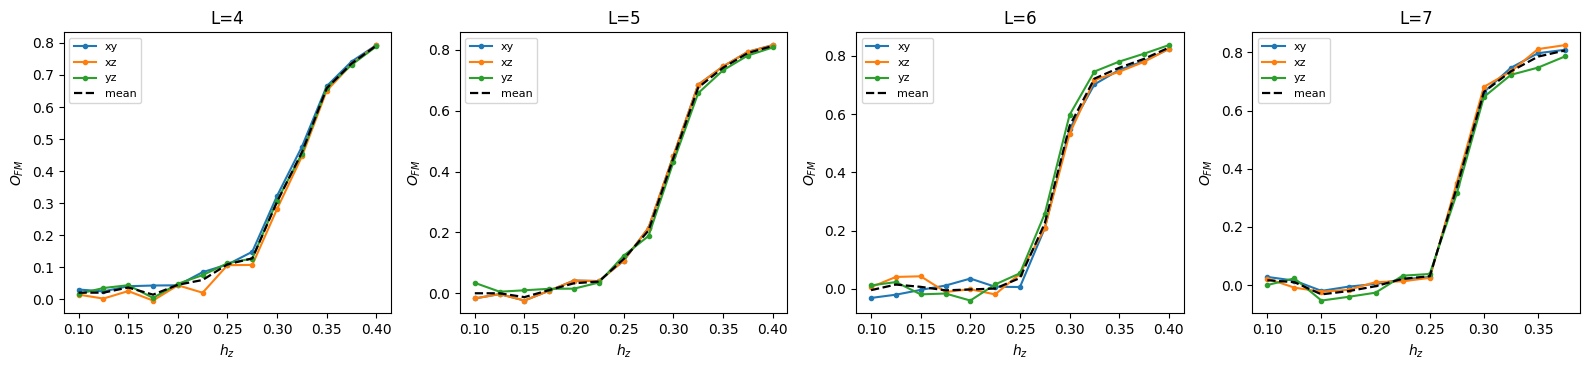

In [15]:
have = [r for r in recs if "O_planes" in r]
if have:
    fig, axs = plt.subplots(1, len(have), figsize=(4 * len(have), 3.8), squeeze=False)
    for axp, rec in zip(axs[0], have):
        hz = np.array(rec["field"], float)
        keep = np.ones(len(hz), bool)
        for h in EXCLUDE.get(rec["L"], []):
            keep &= ~np.isclose(hz, h, atol=1e-6)
        for lbl, ys in rec["O_planes"].items():
            axp.plot(hz[keep], np.array(ys, float)[keep], "o-", ms=3, label=lbl)
        axp.plot(hz[keep], np.array(rec["O"], float)[keep], "k--", lw=1.6, label="mean")
        axp.set(title=f"L={rec['L']}", xlabel="$h_z$", ylabel="$O_{FM}$"); axp.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("no O_planes in these curves (boundary placement or legacy) — nothing to compare")

## 5 · Finite-size scaling  →  h₀

FSS form = power_x   dof = 1
  params: {'h0': 0.2515, 'b': 0.6603, 'x': 1.5103}
  ==>  h_0 = 0.2515 ± 0.0183


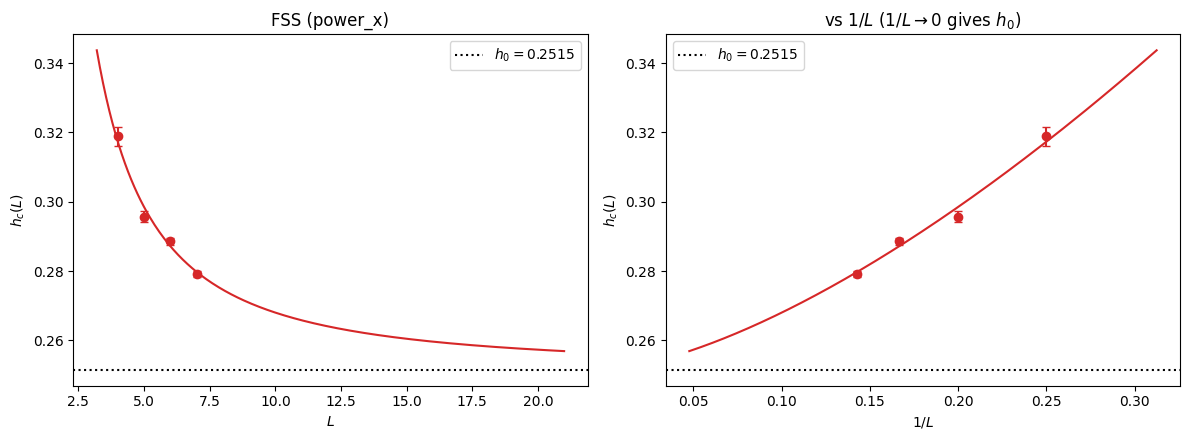

In [16]:
def fss_linear(L, h0, a):       return h0 + a / np.asarray(L, float)
def fss_power_x(L, h0, b, x):   return h0 + (b / np.asarray(L, float)) ** x
def fss_power_free(L, h0, a, w): return h0 + a * np.asarray(L, float) ** (-w)
FSS = {  # name -> (func, param_names, p0)
    "linear_invL": (fss_linear,     ["h0", "a"],      [0.25, 0.5]),
    "power_x":     (fss_power_x,    ["h0", "b", "x"], [0.25, 3.0, 1.0]),
    "power_free":  (fss_power_free, ["h0", "a", "w"], [0.25, 0.5, 1.0]),
}

def fit_fss(fits, form=None, use_Ls=None, fix_x=None, weighted=None, verbose=True):
    """Fit h_c(L) with the chosen form. Returns a dict incl. h0, h0_err, popt, dof,
    and a smooth curve. `fix_x` pins the exponent (power forms) to free a dof."""
    form = FSS_FORM if form is None else form
    use_Ls = FSS_LS if use_Ls is None else use_Ls
    fix_x = FSS_FIX_X if fix_x is None else fix_x
    weighted = WEIGHTED if weighted is None else weighted
    Ls = sorted(fits) if use_Ls is None else sorted(use_Ls)
    L  = np.array(Ls, float)
    hc = np.array([fits[l]["h_c"] for l in Ls])
    he = np.array([fits[l]["h_c_err"] for l in Ls])
    f, names, p0 = FSS[form]
    kw = dict(sigma=he, absolute_sigma=True) if (weighted and np.all(he > 0)) else {}
    fixed = fix_x is not None and form in ("power_x", "power_free")
    try:
        if fixed:
            g = lambda LL, h0, p2: f(LL, h0, p2, fix_x)
            popt2, pcov2 = curve_fit(g, L, hc, p0=p0[:2], maxfev=40000, **kw)
            popt = np.array([popt2[0], popt2[1], fix_x]); h0e = float(np.sqrt(abs(pcov2[0, 0])))
            nfree = 2
        else:
            popt, pcov = curve_fit(f, L, hc, p0=p0, maxfev=40000, **kw)
            h0e = float(np.sqrt(abs(pcov[0, 0]))); nfree = len(p0)
    except Exception as exc:
        if verbose: print(f"[fss:{form}] fit failed: {exc}")
        return dict(form=form, Ls=Ls, L=L, hc=hc, he=he, h0=float("nan"),
                    h0_err=float("nan"), popt=None, dof=len(L) - (2 if fixed else len(p0)))
    dof = len(L) - nfree
    if verbose and dof <= 0:
        print(f"[fss:{form}] WARNING dof={dof}: {len(L)} L-points vs {nfree} free params "
              f"-> exact/underdetermined, h0_err is not meaningful. "
              f"Use linear_invL, FSS_FIX_X, or add more L.")
    LL = np.linspace(L.min() * 0.8, L.max() * 3.0, 300)   # positive -> no 1/0 in the curve
    return dict(form=form, Ls=Ls, L=L, hc=hc, he=he, h0=float(popt[0]), h0_err=h0e,
                popt=popt, names=names, dof=dof, curve=(LL, f(LL, *popt)))

res = fit_fss(fits)
print(f"FSS form = {res['form']}   dof = {res['dof']}")
if res["popt"] is not None:
    print("  params:", {n: round(float(v), 4) for n, v in zip(res["names"], res["popt"])})
print(f"  ==>  h_0 = {res['h0']:.4f} ± {res['h0_err']:.4f}")

# plot h_c(L) vs 1/L with the fit curve and the h_0 asymptote
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].errorbar(res["L"], res["hc"], yerr=res["he"], fmt="o", capsize=3, color="C3")
if res.get("curve") is not None:
    LL, cc = res["curve"]; ax[0].plot(LL, cc, "-", color="C3")
    ax[0].axhline(res["h0"], ls=":", color="k", label=f"$h_0={res['h0']:.4f}$")
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$", title=f"FSS ({res['form']})"); ax[0].legend()
x = 1.0 / res["L"]
ax[1].errorbar(x, res["hc"], yerr=res["he"], fmt="o", capsize=3, color="C3")
if res.get("curve") is not None:
    LL, cc = res["curve"]
    ax[1].plot(1.0 / LL, cc, "-", color="C3")
    ax[1].axhline(res["h0"], ls=":", color="k", label=f"$h_0={res['h0']:.4f}$")
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title=r"vs $1/L$ ($1/L\to0$ gives $h_0$)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6 · Compare h₀ across all FSS forms

Fit every FSS form to the same `h_c(L)`, tabulate `h_0`, **and overlay all three
curves + their `h_0` asymptotes on one axis** (the data points are shared). The
forms should agree if the data are in the scaling regime; a big spread means the
exponent / functional form matters (few L-points → under-constrained, watch `dof`).
Note `power_x` and `power_free` are the *same* model reparametrized, so their
curves coincide — the informative contrast is against `linear_invL`.

         form  dof       h_0   h_0_err   params
  linear_invL    2    0.2305    0.0038   h0=0.23, a=0.342
      power_x    1    0.2515    0.0183   h0=0.252, b=0.66, x=1.51
   power_free    1    0.2515    0.0183   h0=0.252, a=0.534, w=1.51

fixed-exponent power_free (h0 + a*L**-w):
   w=1.0:  h_0 = 0.2305 ± 0.0038
   w=1.5:  h_0 = 0.2512 ± 0.0024
   w=2.0:  h_0 = 0.2616 ± 0.0018


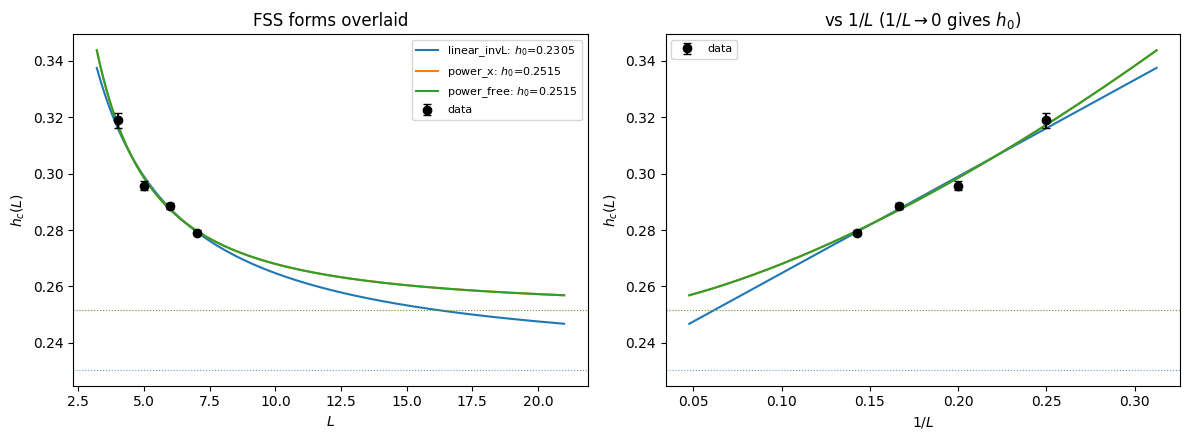

In [17]:
forms = ("linear_invL", "power_x", "power_free")
results = {f: fit_fss(fits, form=f, verbose=False) for f in forms}

print(f"{'form':>13} {'dof':>4} {'h_0':>9} {'h_0_err':>9}   params")
for f in forms:
    r = results[f]
    pstr = ("" if r["popt"] is None else
            ", ".join(f"{n}={float(v):.3g}" for n, v in zip(r["names"], r["popt"])))
    print(f"{f:>13} {r['dof']:>4} {r['h0']:>9.4f} {r['h0_err']:>9.4f}   {pstr}")

# fixed-exponent variants (free a dof at 3 L-points): common mean-field / Ising-ish x
print("\nfixed-exponent power_free (h0 + a*L**-w):")
for w in (1.0, 1.5, 2.0):
    r = fit_fss(fits, form="power_free", fix_x=w, verbose=False)
    print(f"   w={w:>3}:  h_0 = {r['h0']:.4f} ± {r['h0_err']:.4f}")

# ---- overlay all three fits (data shared across forms) ----
d = next(iter(results.values()))              # any result carries the same L, hc, he
col = {"linear_invL": "C0", "power_x": "C1", "power_free": "C2"}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].errorbar(d["L"], d["hc"], yerr=d["he"], fmt="ko", capsize=3, zorder=5, label="data")
ax[1].errorbar(1.0 / d["L"], d["hc"], yerr=d["he"], fmt="ko", capsize=3, zorder=5, label="data")
for f in forms:
    r = results[f]
    if r.get("curve") is None:
        continue
    LL, cc = r["curve"]
    ax[0].plot(LL, cc, "-", color=col[f], label=f"{f}: $h_0$={r['h0']:.4f}")
    ax[0].axhline(r["h0"], ls=":", color=col[f], lw=0.8, alpha=0.7)
    ax[1].plot(1.0 / LL, cc, "-", color=col[f])
    ax[1].axhline(r["h0"], ls=":", color=col[f], lw=0.8, alpha=0.7)
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$", title="FSS forms overlaid"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title=r"vs $1/L$ ($1/L\to0$ gives $h_0$)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7 · Jackknife h₀ (leave-one-L-out)

With only a handful of L-points, `curve_fit`'s covariance is thin. Refit `h_0`
dropping each L in turn — the spread of the jackknife replicates is an honest,
model-light stability check on `h_0` (and flags an L that's driving the answer).

Uses the **2-param `linear_invL`** form (`JK_FORM`) so each leave-one-out subset
(only 2 L-points) stays well-posed; a 3-param form would be underdetermined there.

In [18]:
JK_FORM = "linear_invL"    # 2 params -> each 2-point leave-one-out fit is well-posed
Ls_all = sorted(fits)
if len(Ls_all) >= 3:
    reps = []
    for drop in Ls_all:
        sub = [l for l in Ls_all if l != drop]
        r = fit_fss(fits, form=JK_FORM, use_Ls=sub, verbose=False)
        reps.append((drop, r["h0"]))
        print(f"  drop L={drop}: h_0 = {r['h0']:.4f}   (using L={sub})")
    vals = np.array([h for _, h in reps if np.isfinite(h)])
    full = fit_fss(fits, form=JK_FORM, verbose=False)["h0"]
    print(f"\n  [{JK_FORM}]  full-set h_0 = {full:.4f}   "
          f"jackknife mean = {vals.mean():.4f}   spread (std) = {vals.std(ddof=1):.4f}")
else:
    print("need >=3 L-points to jackknife")

  drop L=4: h_0 = 0.2364   (using L=[5, 6, 7])
  drop L=5: h_0 = 0.2260   (using L=[4, 6, 7])
  drop L=6: h_0 = 0.2298   (using L=[4, 5, 7])
  drop L=7: h_0 = 0.2327   (using L=[4, 5, 6])

  [linear_invL]  full-set h_0 = 0.2305   jackknife mean = 0.2312   spread (std) = 0.0044


## 8 · Compare to theory

Read the L→∞ extrapolation `h_0` against the known theoretical `h_c(hx=0)`. Set
`HZ_C_THEORY` to the thermodynamic-limit value. For each FSS form we report the
deviation `h_0 − theory` and its size in **σ**, folding the `curve_fit`
covariance and the jackknife spread in quadrature (both are thin at 4 L-points,
so read the σ as a rough — not rigorous — significance). The per-L table shows
the finite-size drift of the pseudo-critical `h_c(L)` that the extrapolation
removes; the plot marks `theory` as the red line the fits should hit at `1/L→0`.

In [19]:
# -- 8 - how close is the L->inf extrapolation to theory? ---------------------
HZ_C_THEORY = None      # <-- FILL IN: theoretical h_c at hx=0 (thermodynamic limit)

assert HZ_C_THEORY is not None, "set HZ_C_THEORY above (the theory value at hx=0)"

def _jk_spread(form):
    """leave-one-L-out spread of h_0 as a model-light error (needs >=3 L)."""
    Ls = sorted(fits)
    if len(Ls) < 3:
        return float("nan")
    reps = [fit_fss(fits, form=form, use_Ls=[l for l in Ls if l != d], verbose=False)["h0"]
            for d in Ls]
    reps = np.array([r for r in reps if np.isfinite(r)])
    return float(reps.std(ddof=1)) if len(reps) >= 2 else float("nan")

print(f"theory:  h_c(hx=0) = {HZ_C_THEORY:.4f}\n")
print(f"{'FSS form':>13} {'h_0':>8} {'fit_err':>8} {'jk_err':>7} {'h_0-thy':>9} {'n_sigma':>8}")
for f in ("linear_invL", "power_x", "power_free"):
    r = results[f]
    if r["popt"] is None or not np.isfinite(r["h0"]):
        print(f"{f:>13}   (fit failed)"); continue
    jk = _jk_spread(f)
    err = float(np.hypot(np.nan_to_num(r["h0_err"]), np.nan_to_num(jk)))  # fit + jk in quad
    dev = r["h0"] - HZ_C_THEORY
    nsig = abs(dev) / err if err > 0 else float("nan")
    print(f"{f:>13} {r['h0']:>8.4f} {r['h0_err']:>8.4f} {jk:>7.4f} {dev:>+9.4f} {nsig:>8.2f}")

print("\nper-L h_c(L) vs theory (pseudo-critical -- expect a finite-size drift):")
for l in sorted(fits):
    print(f"   L={l}:  h_c = {fits[l]['h_c']:.4f} +/- {fits[l]['h_c_err']:.4f}"
          f"   (h_c - thy = {fits[l]['h_c'] - HZ_C_THEORY:+.4f})")

# visual: FSS curves vs 1/L with the theory line at 1/L -> 0
fig, ax = plt.subplots(figsize=(6.8, 4.6))
d0 = next(iter(results.values()))
ax.errorbar(1.0 / d0["L"], d0["hc"], yerr=d0["he"], fmt="ko", capsize=3, zorder=5, label="data")
col = {"linear_invL": "C0", "power_x": "C1", "power_free": "C2"}
for f in ("linear_invL", "power_x", "power_free"):
    r = results[f]
    if r.get("curve") is None:
        continue
    LL, cc = r["curve"]
    ax.plot(1.0 / LL, cc, "-", color=col[f], label=f"{f}: $h_0$={r['h0']:.4f}")
    ax.axhline(r["h0"], ls=":", color=col[f], lw=0.8, alpha=0.6)
ax.axhline(HZ_C_THEORY, color="red", lw=1.8, label=f"theory = {HZ_C_THEORY:.4f}")
ax.axvline(0.0, color="gray", lw=0.5)
ax.set(xlabel="$1/L$", ylabel="$h_c(L)$", title="FSS extrapolation vs theory")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

AssertionError: set HZ_C_THEORY above (the theory value at hx=0)